# Plotting

In [20]:
import sys

sys.path.append('..')

### 1. Calculating $v = 2v_0$, $p$ and $T$

$$
    g = 9.8 \; m/s^2
$$

$$
    H = 1 \; m
$$

$$
    L = 1 \; m
$$

$$
    v_0^{min} = \sqrt{g(H + \sqrt{H^2 + L^2})}
$$

$$
    v = 2 v_0^{min}
$$

$$
    D = \frac{v^4}{g^2 L^2} - \frac{2 v^2 H}{g L^2} - 1 \ge 0
$$

$$
    p_{1} = \frac{v^2}{g L} - \sqrt{D}
$$

$$
    p_{2} = \frac{v^2}{g L} + \sqrt{D}
$$

$$
    T_1 = \frac{L}{v_0} \sqrt{1 + p_1^2}
$$

$$
    T_2 = \frac{L}{v_0} \sqrt{1 + p_2^2}
$$

In [21]:
from modules.solver_class import Solver

g = 9.8

H = 1.
L = 1.

solver = Solver(g, H, L)

v0 = solver.calc_v0_min()

v = 2*v0

D = solver.calc_D(v)

p1, p2 = solver.calc_p(v, D)

T1 = solver.calc_flight_time(v, p1)
T2 = solver.calc_flight_time(v, p2)

print(f'v0 = {v0}')
print(f'v = {v}')
print(f'D = {D}')
print(f'p1 = {p1}, p2 = {p2}')
print(f'T1 = {T1}, T2 = {T2}')

v0 = 4.864081918641619
v = 9.728163837283239
D = 72.9411254969543
p1 = 1.1162965688163524, p2 = 18.19741193016841
T1 = 0.15405840981910202, T2 = 1.873412902730202


### 2. Plotting $x_1 = x_1(t_1)$, $y_1 = y_1(t_1)$ and $y_1 = y_1(x_1)$

$$
    x_1 = \frac{v \cdot t_1}{\sqrt{p_1^2 + 1}}
$$

$$
    y_1 = \frac{v \cdot p_1 \cdot t_1}{\sqrt{p_1^2 + 1}} - \frac{gt_1^2}{2}
$$

In [22]:
import numpy as np

N = 10

dt1 = T1/N

t1 = np.array([i*dt1 for i in range(0, N + 1)])

t1

array([0.        , 0.01540584, 0.03081168, 0.04621752, 0.06162336,
       0.0770292 , 0.09243505, 0.10784089, 0.12324673, 0.13865257,
       0.15405841])

In [23]:
x1 = v * t1 / np.sqrt(p1**2 + 1)

x1

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [24]:
y1 = v * p1 * t1 / np.sqrt(p1**2 + 1) - g * t1**2 / 2

y1

array([0.        , 0.11046669, 0.21860745, 0.32442228, 0.42791118,
       0.52907414, 0.62791118, 0.72442228, 0.81860745, 0.91046669,
       1.        ])

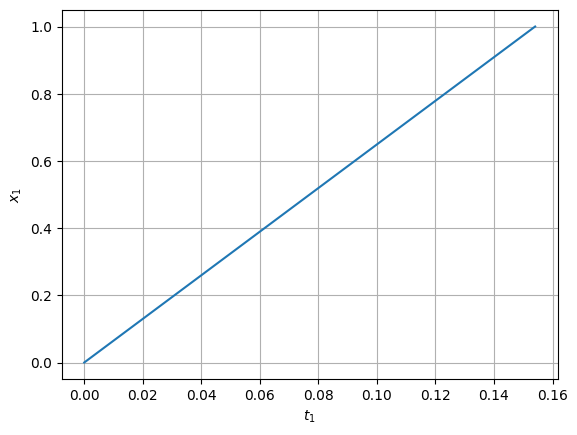

In [25]:
from matplotlib import pyplot as plt

plt.xlabel('$t_1$')
plt.ylabel('$x_1$')

plt.grid(True)

plt.plot(t1, x1)

plt.show()

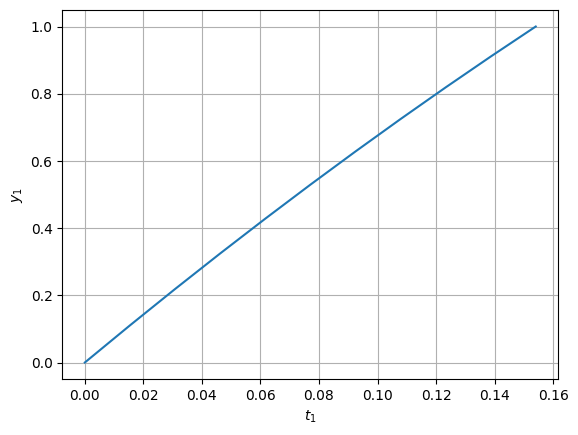

In [26]:
plt.xlabel('$t_1$')
plt.ylabel('$y_1$')

plt.grid(True)

plt.plot(t1, y1)

plt.show()

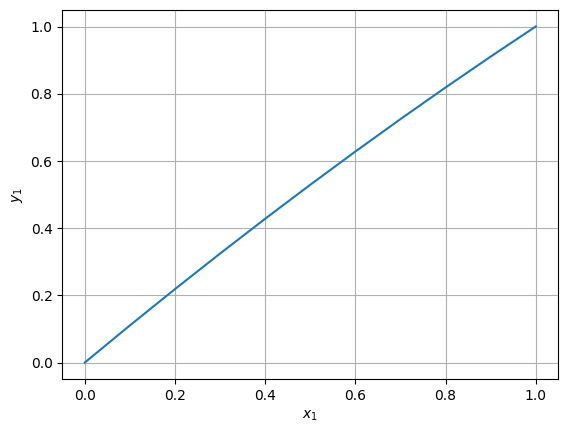

In [27]:
plt.xlabel('$x_1$')
plt.ylabel('$y_1$')

plt.grid(True)

plt.plot(x1, y1)

plt.show()

### 3. Plotting $x_2 = x_2(t_2)$, $y_2 = y_2(t_2)$ and $y_2 = y_2(x_2)$

$$
    x_2 = \frac{v \cdot t_2}{\sqrt{p_2^2 + 1}}
$$

$$
    y_2 = \frac{v \cdot p_2 \cdot t_2}{\sqrt{p_2^2 + 1}} - \frac{gt_2^2}{2}
$$

In [28]:
dt2 = T2/N

t2 = np.array([i*dt2 for i in range(0, N + 1)])

t2

array([0.        , 0.18734129, 0.37468258, 0.56202387, 0.74936516,
       0.93670645, 1.12404774, 1.31138903, 1.49873032, 1.68607161,
       1.8734129 ])

In [29]:
x2 = v * t2 / np.sqrt(p2**2 + 1)

x2

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [30]:
y2 = v * p2 * t2 / np.sqrt(p2**2 + 1) - g * t2**2 / 2

y2

array([0.        , 1.64776707, 2.95158591, 3.91145651, 4.52737886,
       4.79935298, 4.72737886, 4.31145651, 3.55158591, 2.44776707,
       1.        ])

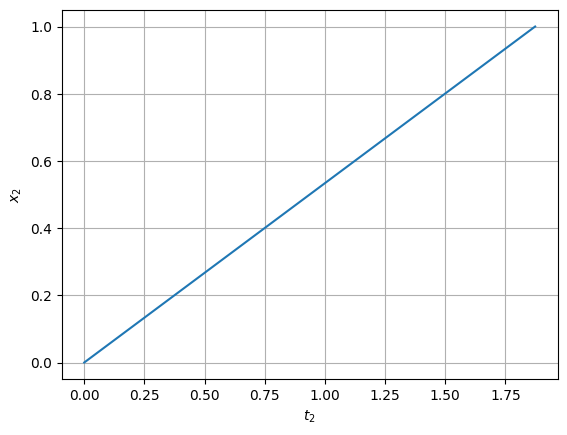

In [31]:
plt.xlabel('$t_2$')
plt.ylabel('$x_2$')

plt.grid(True)

plt.plot(t2, x2)

plt.show()

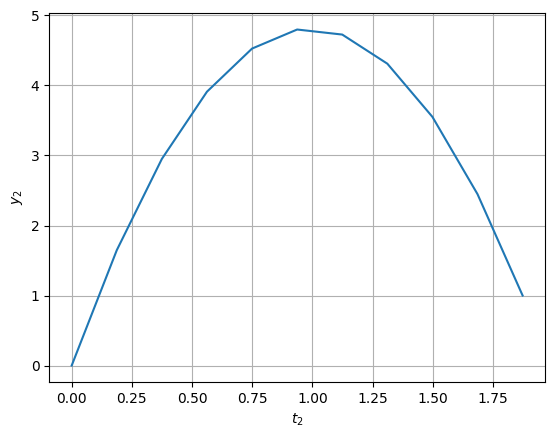

In [32]:
plt.xlabel('$t_2$')
plt.ylabel('$y_2$')

plt.grid(True)

plt.plot(t2, y2)

plt.show()

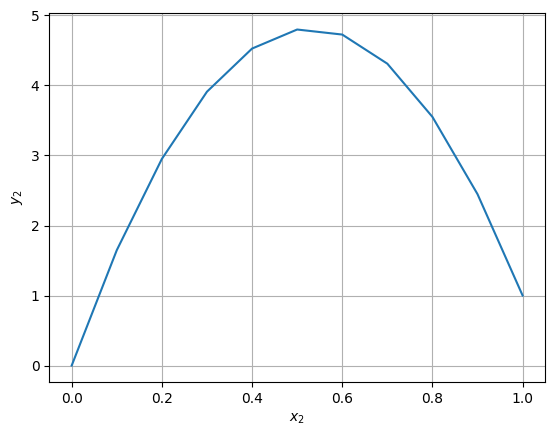

In [33]:
plt.xlabel('$x_2$')
plt.ylabel('$y_2$')

plt.grid(True)

plt.plot(x2, y2)

plt.show()

### 4. Dynamic list

$$
    T = \frac{L}{v \cdot cos\theta} \Rightarrow T_{min} = \frac{L}{v}
$$

$$
    N = 10 \Rightarrow \Delta t = \frac{T_{min}}{N}
$$

In [37]:
from math import sqrt

T = L/v

dt = T/N

t = 0.
x = v * t / sqrt(p1**2 + 1)
y = v * p1 * t / sqrt(p1**2 + 1) - g * t**2 / 2

t1 = [t]
x1 = [x]
y1 = [y]

while x >= 0 and x <= L and y >= 0 and y <= H:
    t += dt
    x = v * t / sqrt(p1**2 + 1)
    y = v * p1 * t / sqrt(p1**2 + 1) - g * t**2 / 2 

    t1.append(t)
    x1.append(x)
    y1.append(y)

In [38]:
t1

[0.0,
 0.01027943213875053,
 0.02055886427750106,
 0.03083829641625159,
 0.04111772855500212,
 0.05139716069375265,
 0.06167659283250318,
 0.07195602497125371,
 0.08223545711000424,
 0.09251488924875477,
 0.1027943213875053,
 0.11307375352625583,
 0.12335318566500636,
 0.1336326178037569,
 0.14391204994250745,
 0.154191482081258]

In [39]:
x1

[0.0,
 0.06672425186538543,
 0.13344850373077086,
 0.20017275559615627,
 0.2668970074615417,
 0.3336212593269271,
 0.40034551119231254,
 0.46706976305769804,
 0.5337940149230834,
 0.6005182667884689,
 0.6672425186538542,
 0.7339667705192398,
 0.8006910223846251,
 0.8674152742500106,
 0.9341395261153962,
 1.0008637779807816]

In [40]:
y1

[0.0,
 0.07396628646120147,
 0.14689703901647022,
 0.21879225766580623,
 0.2896519424092095,
 0.35947609324668,
 0.4282647101782178,
 0.49601779320382283,
 0.5627353423234952,
 0.6284173575372348,
 0.6930638388450416,
 0.7566747862469158,
 0.8192501997428572,
 0.8807900793328658,
 0.9412944250169419,
 1.000763236795085]

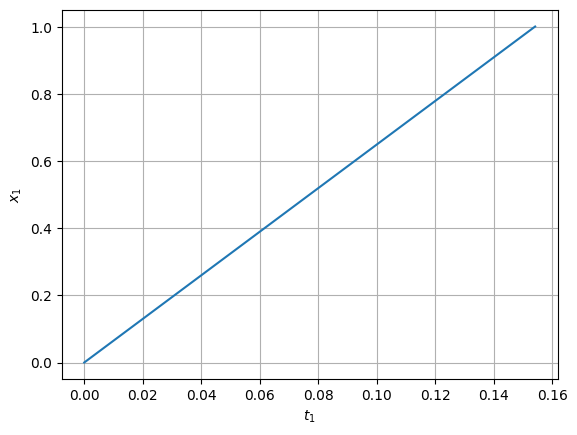

In [41]:
plt.xlabel('$t_1$')
plt.ylabel('$x_1$')

plt.grid(True)

plt.plot(t1, x1)

plt.show()

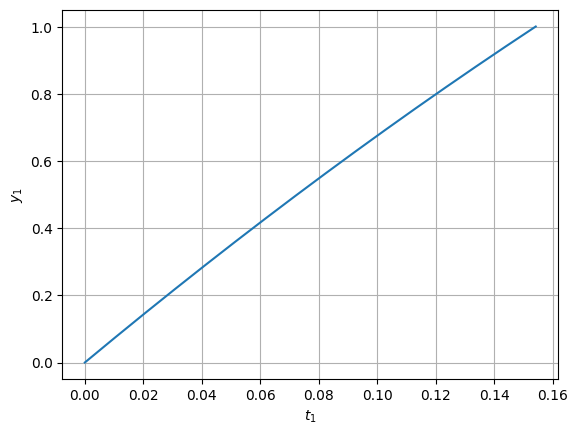

In [42]:
plt.xlabel('$t_1$')
plt.ylabel('$y_1$')

plt.grid(True)

plt.plot(t1, y1)

plt.show()

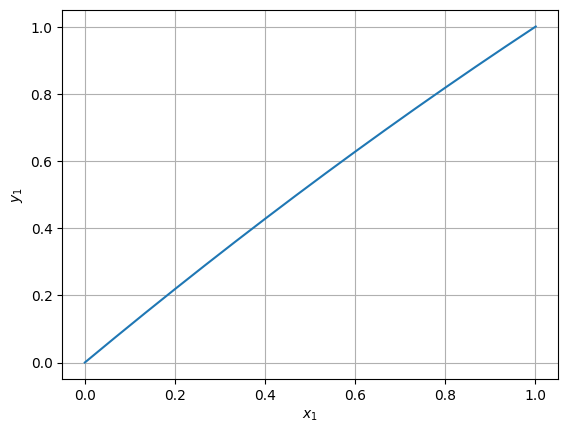

In [43]:
plt.xlabel('$x_1$')
plt.ylabel('$y_1$')

plt.grid(True)

plt.plot(x1, y1)

plt.show()

In [44]:
t = 0.
x = v * t / sqrt(p2**2 + 1)
y = v * p2 * t / sqrt(p2**2 + 1) - g * t**2 / 2

t2 = [t]
x2 = [x]
y2 = [y]

while x >= 0 and x <= L and y >= 0 and y <= H:
    t += dt
    x = v * t / sqrt(p2**2 + 1)
    y = v * p2 * t / sqrt(p2**2 + 1) - g * t**2 / 2 

    t2.append(t)
    x2.append(x)
    y2.append(y)

In [45]:
t2

[0.0,
 0.01027943213875053,
 0.02055886427750106,
 0.03083829641625159,
 0.04111772855500212,
 0.05139716069375265,
 0.06167659283250318,
 0.07195602497125371,
 0.08223545711000424,
 0.09251488924875477,
 0.1027943213875053,
 0.11307375352625583]

In [46]:
x2

[0.0,
 0.005487008295805953,
 0.010974016591611907,
 0.01646102488741786,
 0.021948033183223813,
 0.027435041479029764,
 0.03292204977483572,
 0.038409058070641676,
 0.04389606636644763,
 0.04938307466225358,
 0.05487008295805953,
 0.060357091253865486]

In [47]:
y2

[0.0,
 0.09933158327006593,
 0.19762763263419914,
 0.2948881480923996,
 0.3911131296446673,
 0.4863025772910022,
 0.5804564910314045,
 0.673574870865874,
 0.7656577167944109,
 0.8567050288170149,
 0.946716806933686,
 1.0356930511444244]

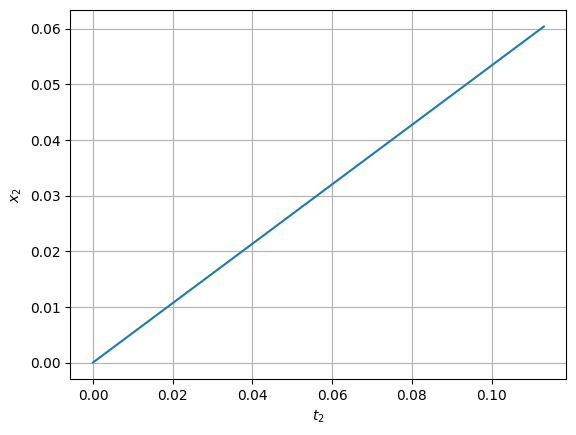

In [48]:
plt.xlabel('$t_2$')
plt.ylabel('$x_2$')

plt.grid(True)

plt.plot(t2, x2)

plt.show()

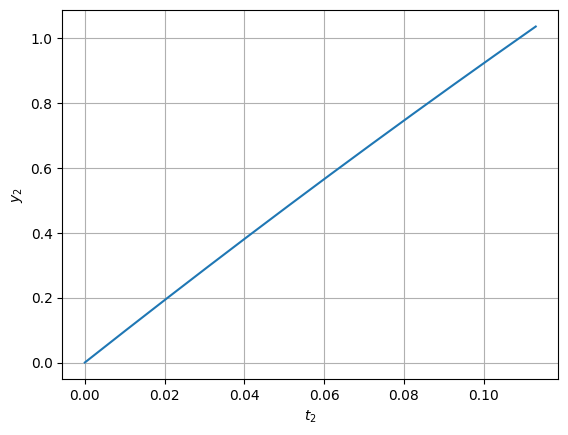

In [49]:
plt.xlabel('$t_2$')
plt.ylabel('$y_2$')

plt.grid(True)

plt.plot(t2, y2)

plt.show()

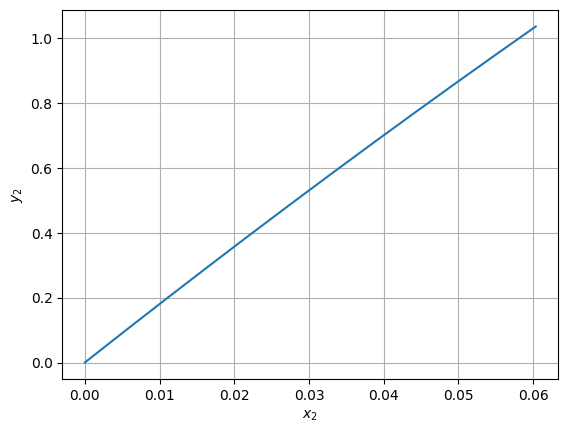

In [50]:
plt.xlabel('$x_2$')
plt.ylabel('$y_2$')

plt.grid(True)

plt.plot(x2, y2)

plt.show()

### 5. Dictionary

$$
    \begin{array}{|c|c|}
        \hline
        Name & Price \; (\text{KZT per kg}) \\
        \hline
        Banana & 3000 \\
        \hline
        Onion & 500 \\
        \hline
        Beetroot & 600 \\
        \hline
        Banana & 2500 \\
        \hline
        Onion & 400 \\
        \hline
        Beetroot & 480 \\
        \hline
        Banana & 3300 \\
        \hline
        Onion & 610 \\
        \hline
        Beetroot & 830 \\
        \hline
        Banana & 2900 \\
        \hline
        Onion & 450 \\
        \hline
        Beetroot & 520 \\
        \hline
    \end{array}
$$

Need to convert to:

$$
    \begin{array}{|c|c|c|c|}
        \hline
        Name & Count & Sum of Prices \; (\text{KZT per kg}) & Average \; (\text{KZT per kg}) \\
        \hline
        Banana & 4 & 11700 & 2925 \\
        \hline
        Onion & 4 & 1960 & 490 \\
        \hline
        Beetroot & 4 & 2430 & 607.5 \\
        \hline        
    \end{array}
$$

In [51]:
list = [
    ('Banana', 3000),
    ('Onion', 500),
    ('Beetroot', 600),
    ('Banana', 2500),
    ('Onion', 400),
    ('Beetroot', 480),
    ('Banana', 3300),
    ('Onion', 610),
    ('Beetroot', 830),
    ('Banana', 2900),
    ('Onion', 450),
    ('Beetroot', 520)
]

dic = {}

for item in list:
    if item[0] in dic:
        data = dic[item[0]]
        dic[item[0]] = (data[0] + 1, data[1] + item[1])
    else:
        dic[item[0]] = (1, item[1])

dic

{'Banana': (4, 11700), 'Onion': (4, 1960), 'Beetroot': (4, 2430)}

In [53]:
dic = {k: (v[0], v[1], v[1]/v[0]) for k, v in dic.items()}

dic

{'Banana': (4, 11700, 2925.0),
 'Onion': (4, 1960, 490.0),
 'Beetroot': (4, 2430, 607.5)}